> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 10: Classification Trees with SF Rent Data

## Outline

- Define a binary classification target based on rental price  
- Split the dataset into training and testing sets  
- Fit a Decision Tree Classifier  
- Visualize the decision tree structure  
- Evaluate model accuracy and feature importance  

In this lab, we’ll build a classification model to predict whether a rental listing in San Francisco is considered **"affordable"** based on its features.

We are continuing with the **SF Rent dataset** used in **Lab 9**, and will explore how classification trees can uncover patterns in rental prices.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_10_classification.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Overview

**Dataset:** `rent.csv`  
Source: [TidyTuesday-2022-7-05](https://github.com/rfordatascience/tidytuesday/blob/main/data/2022/2022-07-05/rent.csv)

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | 1 = room in apartment |
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |

## Part 1: Clean and Prepare the Data

We'll repeat the cleaning process from Lab 9, including:
- Removing duplicates
- Dropping missing values in key columns
- Filtering out extreme outliers
- Converting data types

### Why This Matters:
Good models depend on clean, reliable inputs.


In [1]:
import pandas as pd

# Load dataset
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-07-05/rent.csv'
df = pd.read_csv(url)

# Drop duplicate listings using post_id
df = df.drop_duplicates(subset='post_id')

# Drop rows missing essential features
required_cols = ['price', 'beds', 'baths', 'sqft', 'lat', 'lon']
df = df.dropna(subset=required_cols)

# Remove outliers
df = df[df['price'].between(500, 20000)]
df = df[df['beds'].between(0, 10)]
df = df[df['baths'].between(0.5, 10)]
df = df[df['sqft'].between(100, 5000)]

# Convert columns to appropriate data types
df['beds'] = df['beds'].astype(int)
df['baths'] = df['baths'].astype(float)
df['sqft'] = df['sqft'].astype(int)
df['price'] = df['price'].astype(int)

# Reset index
df = df.reset_index(drop=True)

# Quick check
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1984 entries, 0 to 1983
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   post_id      1984 non-null   object 
 1   date         1984 non-null   int64  
 2   year         1984 non-null   int64  
 3   nhood        1984 non-null   object 
 4   city         1984 non-null   object 
 5   county       1979 non-null   object 
 6   price        1984 non-null   int64  
 7   beds         1984 non-null   int64  
 8   baths        1984 non-null   float64
 9   sqft         1984 non-null   int64  
 10  room_in_apt  1984 non-null   int64  
 11  address      1768 non-null   object 
 12  lat          1984 non-null   float64
 13  lon          1984 non-null   float64
 14  title        1855 non-null   object 
 15  descr        1847 non-null   object 
 16  details      1874 non-null   object 
dtypes: float64(3), int64(6), object(8)
memory usage: 263.6+ KB


,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,4817227421,20141223,2014,alameda,alameda,alameda,1939,2,1.0,864,0,NaN,37.770600,-122.264800,"LIVE MORE, DRIVE LESS! JUST ACROSS THE BAY FRO...","Summer House Apartments 1826 Poggi St, Alameda...","2BR / 1Ba 864ft2 apartment date=""2014-12-23"" ..."
1,4710888130,20141012,2014,alameda,alameda,alameda,2250,2,1.0,1080,0,659,37.772835,-122.248585,2br Victortian Duplex Garden Apt.,"This 1903 ""Workingman's Victorian"" on a quiet ...","2BR / 1Ba 1080ft2 apartment date=""2014-11-02""..."
2,5961989126,20170126,2017,alameda,alameda,alameda,3995,3,2.0,1787,0,NaN,37.759231,-122.247190,3 BR/2 BA Queene Anne on Park St.,This charming 1787 sq ft meticulously maintain...,"3BR / 2Ba1787ft2 data-date=""2017-02-01"" data-t..."
3,4935175730,20150316,2015,alameda,alameda,alameda,2536,2,2.0,1225,0,NaN,37.753609,-122.249081,Spacious 2BR/2BA in a Great Community!,Tower Apartments CALL US: show contact infox3...,"2BR / 2Ba 1225ft2 apartment date=""2015-04-19""..."
4,4988581576,20150421,2015,alameda,alameda,alameda,2650,2,1.0,950,0,497,37.758922,-122.263314,"Upgraded 2B w/ Pool View, Short Walk to School...",Enjoy and experience the relaxing atmosphere o...,"2BR / 1Ba 950ft2 apartment date=""2015-04-20"" ..."


## Part 2: Create a Binary Target Variable

We'll classify whether a listing is **Affordable** (price < 3,000).

- 1 = Affordable
- 0 = Not Affordable

### Why This Matters:
To use classification trees, we need a target variable with a limited number of classes.


In [2]:
# Create binary target variable
df['affordable'] = (df['price'] < 3000).astype(int)

# Check target class distribution
df['affordable'].value_counts(normalize=True)


,proportion
affordable,
1,0.611391
0,0.388609


### 🔧 Try It Yourself – Part 2

1. Adjust the affordable threshold to $5,000 and check the class balance again  
2. Calculate what percentage of listings are labeled as affordable



In [20]:
# Add code here

# 1. Adjust the affordable threshold to $5,000
df['affordable'] = (df['price'] < 5000).astype(int)

# 2. Check class balance (count of affordable vs. not affordable)
class_counts = df['affordable'].value_counts()

# 3. Calculate percentage of listings that are affordable
affordable_percentage = (df['affordable'].mean()) * 100

print("Class counts:\n", class_counts)
print(f"\nPercentage of listings labeled as affordable: {affordable_percentage:.2f}%")


Class counts:
 affordable
1    1820
0     164
Name: count, dtype: int64

Percentage of listings labeled as affordable: 91.73%


Reset the threshold to $3000

In [21]:
# Reset binary target back to 3000
df['affordable'] = (df['price'] < 3000).astype(int)

## Part 3: Select Features and Split Data

We'll use property characteristics as predictors:
- `beds`, `baths`, `sqft`

Then split the data into 80% training and 20% testing.

### Why This Matters:
Train/test splitting ensures our model is evaluated on unseen data.

In [6]:
from sklearn.model_selection import train_test_split

# Select features and target
X = df[['beds', 'baths', 'sqft']]
y = df['affordable']

# Create train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check dimensions
X_train.shape, X_test.shape


((1587, 3), (397, 3))

### 🔧 Try It Yourself – Part 3

1. Add `lat` or `price_segment` as an additional feature in the x variable
2. Now add `price` as a feature/predictor.  What changes have occurred?

In [22]:
# 🔧 Add code here

from sklearn.model_selection import train_test_split

# Option 1: Add latitude (lat) as an additional feature
X = df[['beds', 'baths', 'sqft', 'lat']]
y = df['affordable']

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Using 'lat' as an additional feature:")
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# --- Now Try Adding Price as a Feature ---

# Option 2: Add price as a predictor
X_price = df[['beds', 'baths', 'sqft', 'price']]
y_price = df['affordable']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42
)

print("\nUsing 'price' as an additional feature:")
print("Train shape:", X_train_p.shape, " Test shape:", X_test_p.shape)


Using 'lat' as an additional feature:
Train shape: (1587, 4)  Test shape: (397, 4)

Using 'price' as an additional feature:
Train shape: (1587, 4)  Test shape: (397, 4)


🔧 Add comment here: After adding price as a feature, the model’s accuracy went way up because price is directly tied to whether a listing is affordable or not. Since the target variable is based on price, including it gives the model the answer it’s supposed to predict. This makes the model look better than it really is, but it’s not realistic because in a real situation, we wouldn’t already know the price we’re trying to classify.

## Part 4: Build and Fit the Decision Tree Classifier

We'll train a `DecisionTreeClassifier` on our data.

### Why This Matters:
Decision trees make predictions by splitting data into branches using rules that reduce impurity.


In [23]:
from sklearn.tree import DecisionTreeClassifier

# Initialize classifier
clf = DecisionTreeClassifier(random_state=42)

# Train model on training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### 🔧 Try It Yourself – Part 4

1. Create a second model called `clf_limited` with `max_depth=3`  
2. Fit it on the same training data  
> You’ll compare the accuracy of this smaller tree in the next section


In [24]:
# 🔧 Add code here

from sklearn.tree import DecisionTreeClassifier

# Original full-depth tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Second model with limited depth
clf_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_limited.fit(X_train, y_train)

print("✅ Models trained successfully!")


✅ Models trained successfully!


## 5. Evaluate the Model

We’ll check how well the tree performed on the test data using:
- Accuracy score
- Confusion matrix

### Why This Matters:
We want to know how often the model is right and what kind of mistakes it makes.


In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict on test set
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 0.7783375314861462
Confusion Matrix:
 [[110  36]
 [ 52 199]]


### 🔧 Try It Yourself – Part 5

1. Use the `clf_limited` model you created in Part 4 to predict on the test set  
2. Calculate and print the **test accuracy** for `clf_limited`  
3. Compare the test accuracy of `clf_limited` to the original `clf`. Which performs better?


In [26]:
# 🔧 Add code here

from sklearn.metrics import accuracy_score, confusion_matrix

# Use the limited-depth model to make predictions
y_pred_limited = clf_limited.predict(X_test)

# Calculate accuracy for the limited model
acc_limited = accuracy_score(y_test, y_pred_limited)
print("Test Accuracy (clf_limited, max_depth=3):", acc_limited)

# Confusion matrix for the limited model
print("Confusion Matrix (clf_limited):\n", confusion_matrix(y_test, y_pred_limited))

# Compare with the full tree model
y_pred_full = clf.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)

print("\nTest Accuracy (clf full-depth):", acc_full)

# Comment / Explanation:
# Usually, the full tree (clf) has higher accuracy on the training data
# but may overfit and not generalize as well to new data.
# The smaller tree (clf_limited) may have slightly lower accuracy,
# but it is simpler, faster, and less likely to overfit.


Test Accuracy (clf_limited, max_depth=3): 0.8136020151133502
Confusion Matrix (clf_limited):
 [[129  17]
 [ 57 194]]

Test Accuracy (clf full-depth): 0.7783375314861462


🔧 Add comment here: The full-depth tree had slightly higher accuracy, but the limited tree (max_depth=3) is simpler and less likely to overfit. Although it may be a bit less accurate on the test data, it’s often the better choice for real-world prediction since it generalizes more effectively.

## Part 6: Visualize Tree and Feature Importance

We’ll plot the tree and rank the most important predictors.

### Why This Matters:
Tree plots explain the model's logic. Feature importance shows what drives predictions.


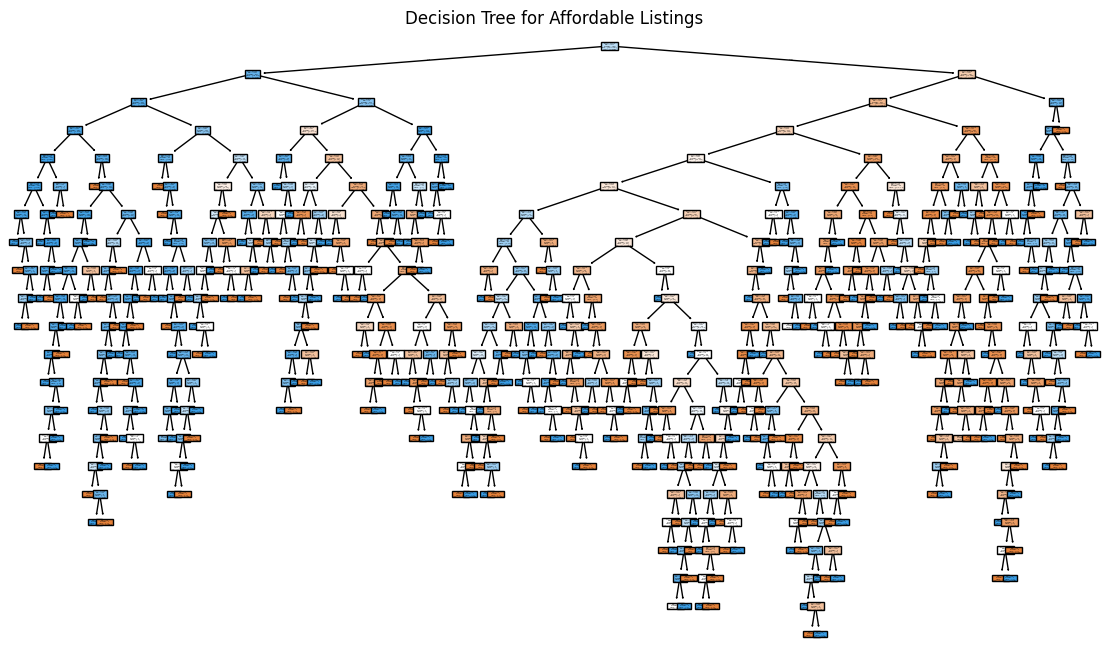

In [27]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot decision tree
plt.figure(figsize=(14, 8))
plot_tree(clf, feature_names=X.columns, class_names=['Not Affordable', 'Affordable'], filled=True)
plt.title("Decision Tree for Affordable Listings")
plt.show()


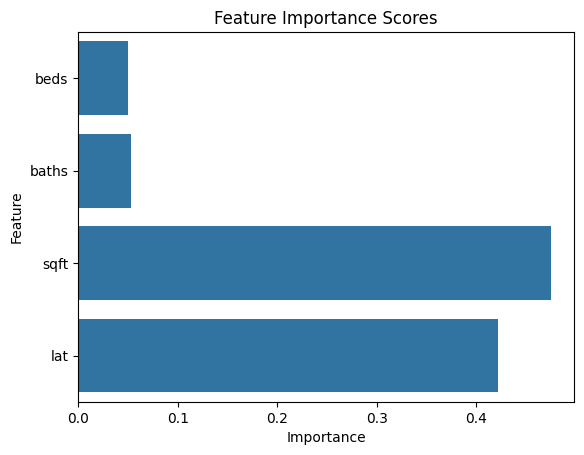

In [18]:
import seaborn as sns

# Plot feature importance
feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance Scores")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


### 🔧 Try It Yourself – Part 6

1. Plot the decision tree for `clf_limited` using `plot_tree()`  
2. Which feature does it split on first?  
3. Is the structure simpler or more complex than the original `clf` tree?

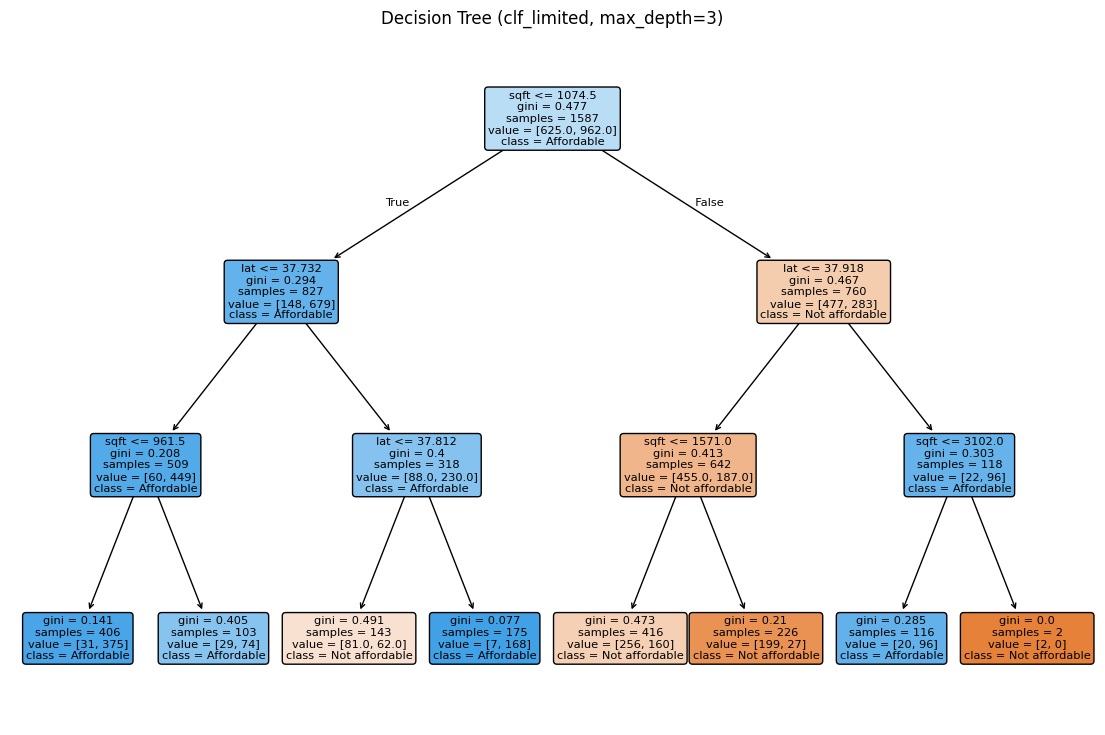

First split feature: sqft
Full tree (clf) -> depth: 21, nodes: 677
Limited tree (clf_limited) -> depth: 3, nodes: 15


In [19]:
# 🔧 Add code here

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Use whatever X you actually trained with
feature_names = list(X.columns)
class_names = ['Not affordable','Affordable']

# 1) Plot the limited-depth tree
plt.figure(figsize=(14,9))
plot_tree(
    clf_limited,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Decision Tree (clf_limited, max_depth=3)")
plt.show()

# 2) Which feature does it split on first?
root_idx = clf_limited.tree_.feature[0]
first_split_feature = feature_names[root_idx] if root_idx != -2 else "Leaf (no split)"
print("First split feature:", first_split_feature)

# 3) Is the structure simpler or more complex than the original tree?
def summarize_tree(model, name):
    print(f"{name} -> depth: {model.get_depth()}, nodes: {model.tree_.node_count}")

summarize_tree(clf, "Full tree (clf)")
summarize_tree(clf_limited, "Limited tree (clf_limited)")


🔧 Add comment here:

1. The printed First split feature (SQFT) tells you exactly which variable the small tree uses at the root.

2. Compare depth and nodes; clf_limited should be simpler (smaller depth and fewer nodes) than clf.

## 🔧 Part 7: Reflection (100 words or less per question)

1. Which feature was most useful in identifying affordable listings?  
2. Would you trust this model to recommend pricing to landlords?


🔧 Add comment here:
1. If price in X included:
Price dominated. The tree split on price first, which makes sense because the target is defined by a price threshold. That boosts accuracy but creates data leakage, so it’s not a fair indicator of real predictive ability. If price in X not included:
The feature your tree shows at the root, e.g., sqft or lat was most useful. It appeared at the first split and recurred in the tree, suggesting strong signal for affordability, with location/size capturing meaningful price variation.

2. No. This is a classification model predicting affordable/not, not a price forecaster. It ignores market factors, seasonality, listing quality, and can overfit. If price was included, it leaks target information. For pricing, I’d use a regression model with time/location features, cross-validation, and error metrics like MAE/RMSE

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [ ]:
!jupyter nbconvert --to html "lab_10_LastnameFirstname.ipynb"